# Explorating the Data and selecting the data to process

In [6]:
%matplotlib widget
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from dataclasses import dataclass

# Add the root folder (where 'spectra' lives) to sys.path
ROOT = r"H:\FUBerlin\DataAnalysis"
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from spectra.io import load_absorption_csv

# ============================================================
# 1. STYLE & OBJECT CONFIGURATION
# ============================================================
@dataclass
class Spectrum:
    N: str                        # Name or Label
    X: np.ndarray                 # Wavelength (nm)
    Y: np.ndarray                 # Absorbance / Intensity
    wcorr: float = 0.0            # Water correction factor
    color: str = None             # Custom line color
    linestyle: str = None         # Custom linestyle
    
    @property
    def E(self):
        """Automatically calculates energy in eV (E = 1240 / Wavelength)"""
        return np.divide(1240.0, self.X, out=np.zeros_like(self.X), where=self.X != 0)

    def copy(self):
        """Returns a deep copy of the spectrum preserving all properties"""
        return Spectrum(
            N=self.N, 
            X=self.X.copy(), 
            Y=self.Y.copy(), 
            wcorr=self.wcorr, 
            color=self.color,          
            linestyle=self.linestyle  
        )

poster_style = {
    "figsize": (6, 5),          
    "dpi": 150,                   
    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 8,
    "line_width": 1.2,
    "font_family": "Calibri",
    "grid": False,               
    "colors": ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"], 
    "linestyles": ["-", "-", "-", "-"]
}

# ============================================================
# 2. PROCESSING FUNCTIONS
# ============================================================
def TrimSpectra(spectra_input, xmin=None, xmax=None):
    if isinstance(spectra_input, Spectrum):
        new_s = spectra_input.copy()
        mask = np.ones_like(new_s.X, dtype=bool)
        if xmin is not None: mask &= (new_s.X >= xmin)
        if xmax is not None: mask &= (new_s.X <= xmax)
        if not np.any(mask):
            print(f"Warning: empty trim range for {new_s.N}")
            return new_s
        new_s.X = new_s.X[mask]
        new_s.Y = new_s.Y[mask]
        return new_s

    res = []
    for s in spectra_input:
        new_s = s.copy()
        mask = np.ones_like(new_s.X, dtype=bool)
        if xmin is not None: mask &= (new_s.X >= xmin)
        if xmax is not None: mask &= (new_s.X <= xmax)
        if not np.any(mask):
            print(f"Warning: empty trim range for {new_s.N}")
            continue
        new_s.X = new_s.X[mask]
        new_s.Y = new_s.Y[mask]
        res.append(new_s)
    return res

def NormalizeSpectra(spectra_list, xmin, xmax, mode="M"):
    res = []
    for s in spectra_list:
        new_s = s.copy()
        mask = (new_s.X >= xmin) & (new_s.X <= xmax)
        X_win, Y_win = new_s.X[mask], new_s.Y[mask]
        if len(X_win) == 0:
            print(f"Warning: No data in range for {new_s.N}")
            continue
        
        if mode.upper() == "M": 
            factor = np.max(Y_win)
        elif mode.upper() == "I": 
            factor = np.trapezoid(Y_win, X_win)
        elif mode.upper() == "V": 
            factor = np.min(Y_win)
        else: 
            raise ValueError("Invalid mode")
        
        if factor == 0:
            print(f"Warning: Zero normalization factor for {new_s.N}")
            continue
            
        new_s.Y = new_s.Y / factor
        new_s.N = new_s.N + f"_norm{mode.upper()}"
        res.append(new_s)
    return res

def PlotSpectra(
        spectra_list, mode="W", style=poster_style, offset_step=0.0,
        xmin=None, xmax=None, ymin=None, ymax=None, 
        xlabel_W="Wavelength (nm)", xlabel_E="Energy (eV)", ylabel="Absorbance",
        custom_colors=None, custom_linestyles=None, 
        hide_yticks=False
):
    fig, ax1 = plt.subplots(figsize=style["figsize"], dpi=style["dpi"])
    plt.rcParams.update({"font.size": style["font_size"], "font.family": style["font_family"]})
    
    default_colors = style.get("colors") or ["#000000"]
    default_linestyles = style.get("linestyles") or ["-"]
    
    for i, s in enumerate(spectra_list):
        y_offset = s.Y + (i * offset_step)
        
        c = getattr(s, 'color', None) or (custom_colors[i] if custom_colors and i < len(custom_colors) else default_colors[i % len(default_colors)])
        ls = getattr(s, 'linestyle', None) or (custom_linestyles[i] if custom_linestyles and i < len(custom_linestyles) else default_linestyles[i % len(default_linestyles)])

        if mode in ["W", "WE"]:
            ax1.plot(s.X, y_offset, label=s.N, linewidth=style["line_width"], color=c, linestyle=ls)
            ax1.set_xlabel(xlabel_W, fontsize=style["label_size"])
        elif mode in ["E", "EW"]:
            ax1.plot(s.E, y_offset, label=s.N, linewidth=style["line_width"], color=c, linestyle=ls)
            ax1.set_xlabel(xlabel_E, fontsize=style["label_size"])

    ax1.set_ylabel(ylabel, fontsize=style["label_size"])
    ax1.set_title("Absorption Spectra", fontsize=style["title_size"])
    
    if xmin is not None or xmax is not None: ax1.set_xlim(xmin, xmax)
    if ymin is not None or ymax is not None: ax1.set_ylim(ymin, ymax)
    if style.get("grid", False): ax1.grid(True, alpha=0.3)
    if hide_yticks: ax1.set_yticklabels([])

    if mode in ["WE", "EW"]:
        ax2 = ax1.twiny()
        ax2.set_xlim(ax1.get_xlim()) 
        ticks = ax1.get_xticks()
        valid_ticks = ticks[ticks > 0]
        ax2.set_xticks(valid_ticks)
        
        if mode == "WE":
            ax2.set_xlabel(xlabel_E, fontsize=style["label_size"])
            ax2.set_xticklabels(np.round(1240.0 / valid_ticks, 2))
        elif mode == "EW":
            ax2.set_xlabel(xlabel_W, fontsize=style["label_size"])
            ax2.set_xticklabels(np.round(1240.0 / valid_ticks, 1))

    ax1.legend(fontsize=style["legend_size"], frameon=False)
    plt.tight_layout()
    plt.show()



In [7]:
# ============================================================
# 3. LOAD DATA FROM FOLDERS
# ============================================================
data_folders = [
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260226_Abs_CNTDispersions_TS',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260330_CNT_CF_PLE_P2_NoPo_CoMoCat_R1',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260701_P2Samples_1pcDOCD2O_P2_F005_F006',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260430_F005_6FBz_AP_1hCF',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260513_F005_6FBz_AP_1hCF_Refs',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260529_F005_6FBz@P2_and_P2_References',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260625_F001_FBz_F002_6FBz_Washing',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260701_PLE_Samples_F005_F006',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260729_D2OSamples_F001_F007_Refs',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260731_DGU_D2OBased_P2_F005LP_F006_F007',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260803_PostDial_P2_F005LP_F006_F007',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260804_PLE_PostDial_P2_F005LP_F006_F007_NI',
]

spectra_dict = {}

for data_folder in data_folders:
    if os.path.exists(data_folder):
        for file in os.listdir(data_folder):
            if file.lower().endswith(".csv"):
                csv_path = os.path.join(data_folder, file)
                try:
                    spectra = load_absorption_csv(csv_path)
                    for s in spectra:
                        # Wrap raw loaded spectrum into our advanced Spectrum dataclass
                        spectra_dict[s.N] = Spectrum(
                            N=s.N,
                            X=np.array(s.X, dtype=float),
                            Y=np.array(s.Y, dtype=float)
                        )
                        print("'"+s.N+"',")

                except Exception as e:
                    print(f"Error loading {file}: {e}")

print(f"\nLoaded {len(spectra_dict)} spectra successfully.")



'20260226_BaselineA',
'20260226_BaselineB',
'20260226_P2R2A',
'20260226_P2R2B',
'20260226_P2R2C',
'20260226_P2R2D',
'20260226_P2_TS_R2_d1',
'20260226_P2_TS_R1_d1',
'20260226_NI_BS_d4',
'20260226_NI_BS_d8',
'20260226_NI_TS_R1_d2',
'20260226_NI_TS_R2_d2',
'20260226_NoPo_TS_R1_d1',
'20260226_NoPo_TS_R2_d1',
'20260226_CoMoB_TS_R1_d1',
'20260226_CoMoB_TS_R2_d1',
'20260226_CoMoY_TS_R1_d1',
'20260226_CoMoY_TS_R2_d1',
'20260330_B',
'20260330_NoPo',
'20260330_NoPo_CF_1',
'20260330_CoMoB_CF_1',
'20260330_P2_CF_1',
'20260330_Sample76',
'20260701_DOC_H2O',
'20260701_P2_inD2O_CF260701_dilA',
'20260701_P2_inD2O_CF260701_dilB',
'20260701_P2_inD2O_CF260701_dilC',
'20260701_F005_6FBz@P2_inD2O_CF260701_dilA',
'20260701_F006_phDADQ@P2_inD2O_CF260701_dilA',
'20260430_H2O@P2_1hCF_d1',
'20260430_AP_6FBz@P2_1hCF_d1',
'20260513_Baseline',
'20260513_P2_Ref_260217_BS',
'20260513_P2_Ref_260224_TS',
'20260513_6FBz_P2_260402',
'20260529_P2_NoSon_CF_0317_d2_A',
'20260529_P2_NoSon_CF_0317_d2_B',
'20260529_P2_NoSon_C

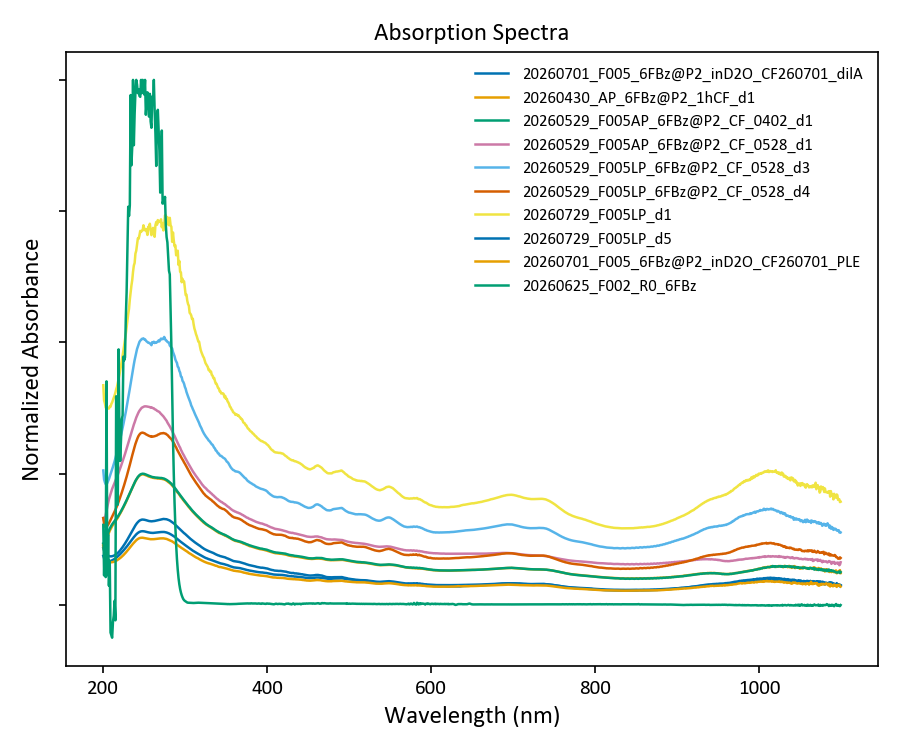

In [8]:
# ============================================================
# 4. SELECT, PIPELINE & PLOT
# ============================================================
selected_names = [ 
#P2 References %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% 
 
    #'20260226_P2R2A', 
    #'20260226_P2R2B', 
    #'20260226_P2R2C', 
    #'20260226_P2R2D', 
    #'20260226_P2_TS_R2_d1', 
    #'20260226_P2_TS_R1_d1', 
    #'20260330_P2_CF_1', 
    #'20260330_Sample76', 
    #'20260701_P2_inD2O_CF260701_dilA', 
    #'20260701_P2_inD2O_CF260701_dilB', 
    #'20260701_P2_inD2O_CF260701_dilC', 
    #'20260430_H2O@P2_1hCF_d1', 
    #'20260513_P2_Ref_260217_BS', 
    #'20260513_P2_Ref_260224_TS', 
    #'20260529_P2_NoSon_CF_0317_d2_A', 
    #'20260529_P2_NoSon_CF_0317_d2_B', 
    #'20260529_P2_NoSon_CF_0528_d3_A', 
    #'20260529_P2_NoSon_CF_0528_d3_B', 
    #'20260529_P2_TipSonR1_CF_0217_d1', 
    #'20260529_P2_TipSonR2_CF_0224_d1', 
    #'20260529_P2_Reference_CF_0217_d1_weirdPlasmon', 
    #'20260529_P2_TipSon_CF_0528_d1', 
    #'20260729_P2_d1', 
    #'20260729_P2_d5', 
 
#CF Sample %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% 
 
    '20260701_F005_6FBz@P2_inD2O_CF260701_dilA', 
    '20260430_AP_6FBz@P2_1hCF_d1', 
    '20260529_F005AP_6FBz@P2_CF_0402_d1', 
    '20260529_F005AP_6FBz@P2_CF_0528_d1', 
    '20260529_F005LP_6FBz@P2_CF_0528_d3', 
    '20260529_F005LP_6FBz@P2_CF_0528_d4', 
    '20260729_F005LP_d1', 
    '20260729_F005LP_d5', 
    '20260701_F005_6FBz@P2_inD2O_CF260701_PLE', 
    
#WASHING STEPS%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% 
    '20260625_F002_R0_6FBz', 
 
 
#DGU AND POST DGU %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% 
 
    #'20260731_P2_DGU_B_d1', 
    #'20260731_P2_DGU_C_d1', 
    #'20260731_P2_DGU_D_d1', 
    #'20260731_P2_DGU_D_d4', 
 
    #'20260731_F005LP_6FBz@P2_DGU_B_d1', 
    #'20260731_F005LP_6FBz@P2_DGU_C_d1', 
    #'20260731_F005LP_6FBz@P2_DGU_D_d1', 
    #'20260731_F005LP_6FBz@P2_DGU_D_d4', 
 
    #'20260803_P2_DGUdial', 
 
    #'20260803_F005LP_6FBz@P2_DGUdial', 
    #'20260804_P2_DGUdial', 
    #'20260804_F005LP_6FBz@P2_DGUdial', 
]

# Gather selected spectra safely
selected_spectra = []
for name in selected_names:
    if name in spectra_dict:
        selected_spectra.append(spectra_dict[name].copy())
    else:
        print(f"Warning: '{name}' not found in loaded spectra!")

# Run through pipeline
selected_spectra = TrimSpectra(selected_spectra, xmin=200, xmax=1100)
#selected_spectra = NormalizeSpectra(selected_spectra, xmin=800, xmax=900, mode="V")

# Plot using the advanced PlotSpectra function
PlotSpectra(
    spectra_list=selected_spectra, 
    mode="W",          # Options: "W", "E", "WE", "EW"
    offset_step=0.0,    # Adjust vertical offset if needed
    ylabel="Normalized Absorbance",
    hide_yticks=True)

save_dir = r"H:\FUBerlin\Writing and Summaries\6FBz@P2-SWCNTs\Figures\Absorption"


plt.savefig(
    save_dir + r"\AbsorptionOverview.png",
    dpi=300,
    bbox_inches="tight"
)


# Upgraded version with SpectraConfig

In [9]:
%matplotlib widget
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from dataclasses import dataclass

# Add the root folder (where 'spectra' lives) to sys.path
ROOT = r"H:\FUBerlin\DataAnalysis"
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from spectra.io import load_absorption_csv

# ============================================================
# 1. STYLE & OBJECT CONFIGURATION
# ============================================================
@dataclass
class Spectrum:
    N: str                        # Name or Label
    X: np.ndarray                 # Wavelength (nm)
    Y: np.ndarray                 # Absorbance / Intensity
    wcorr: float = 0.0            # Water correction factor
    color: str = None             # Custom line color
    linestyle: str = None         # Custom linestyle
    
    @property
    def E(self):
        """Automatically calculates energy in eV (E = 1240 / Wavelength)"""
        return np.divide(1240.0, self.X, out=np.zeros_like(self.X), where=self.X != 0)

    def copy(self):
        """Returns a deep copy of the spectrum preserving all properties"""
        return Spectrum(
            N=self.N, 
            X=self.X.copy(), 
            Y=self.Y.copy(), 
            wcorr=self.wcorr, 
            color=self.color,          
            linestyle=self.linestyle  
        )

poster_style = {
    "figsize": (6, 5),          
    "dpi": 200,                   
    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 8,
    "line_width": 1.2,
    "font_family": "Calibri",
    "grid": False,               
    "colors": ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"], 
    "linestyles": ["-", "--", "-.", ":"]
}

# ============================================================
# 2. PROCESSING & CORRECTION FUNCTIONS
# ============================================================
def PlotSpectra(
        spectra_list, mode="W", style=poster_style, offset_step=0.0,
        xmin=None, xmax=None, ymin=None, ymax=None, 
        xlabel_W="Wavelength (nm)", xlabel_E="Energy (eV)", ylabel="Absorbance",
        custom_colors=None, custom_linestyles=None, 
        hide_yticks=False
):
    fig, ax1 = plt.subplots(figsize=style["figsize"], dpi=style["dpi"])
    plt.rcParams.update({"font.size": style["font_size"], "font.family": style["font_family"]})
    
    default_colors = style.get("colors") or ["#000000"]
    default_linestyles = style.get("linestyles") or ["-"]
    
    for i, s in enumerate(spectra_list):
        y_offset = s.Y + (i * offset_step)
        
        c = getattr(s, 'color', None) or (custom_colors[i] if custom_colors and i < len(custom_colors) else default_colors[i % len(default_colors)])
        ls = getattr(s, 'linestyle', None) or (custom_linestyles[i] if custom_linestyles and i < len(custom_linestyles) else default_linestyles[i % len(default_linestyles)])

        if mode in ["W", "WE"]:
            ax1.plot(s.X, y_offset, label=s.N, linewidth=style["line_width"], color=c, linestyle=ls)
            ax1.set_xlabel(xlabel_W, fontsize=style["label_size"])
        elif mode in ["E", "EW"]:
            ax1.plot(s.E, y_offset, label=s.N, linewidth=style["line_width"], color=c, linestyle=ls)
            ax1.set_xlabel(xlabel_E, fontsize=style["label_size"])

    ax1.set_ylabel(ylabel, fontsize=style["label_size"])
    ax1.set_title("Absorption Spectra", fontsize=style["title_size"])
    
    if xmin is not None or xmax is not None: ax1.set_xlim(xmin, xmax)
    if ymin is not None or ymax is not None: ax1.set_ylim(ymin, ymax)
    if style.get("grid", False): ax1.grid(True, alpha=0.3)
    if hide_yticks: ax1.set_yticklabels([])

    if mode in ["WE", "EW"]:
        ax2 = ax1.twiny()
        ax2.set_xlim(ax1.get_xlim()) 
        ticks = ax1.get_xticks()
        valid_ticks = ticks[ticks > 0]
        ax2.set_xticks(valid_ticks)
        
        if mode == "WE":
            ax2.set_xlabel(xlabel_E, fontsize=style["label_size"])
            ax2.set_xticklabels(np.round(1240.0 / valid_ticks, 2))
        elif mode == "EW":
            ax2.set_xlabel(xlabel_W, fontsize=style["label_size"])
            ax2.set_xticklabels(np.round(1240.0 / valid_ticks, 1))

    ax1.legend(fontsize=style["legend_size"], frameon=False)
    plt.tight_layout()
    plt.show()

def TrimSpectra(spectra_input, xmin=None, xmax=None):
    if isinstance(spectra_input, Spectrum):
        new_s = spectra_input.copy()
        mask = np.ones_like(new_s.X, dtype=bool)
        if xmin is not None: mask &= (new_s.X >= xmin)
        if xmax is not None: mask &= (new_s.X <= xmax)
        if not np.any(mask): return new_s
        new_s.X = new_s.X[mask]
        new_s.Y = new_s.Y[mask]
        return new_s

    res = []
    for s in spectra_input:
        new_s = s.copy()
        mask = np.ones_like(new_s.X, dtype=bool)
        if xmin is not None: mask &= (new_s.X >= xmin)
        if xmax is not None: mask &= (new_s.X <= xmax)
        if not np.any(mask): continue
        new_s.X = new_s.X[mask]
        new_s.Y = new_s.Y[mask]
        res.append(new_s)
    return res

def NormalizeSpectra(spectra_list, xmin, xmax, mode="M"):
    res = []
    for s in spectra_list:
        new_s = s.copy()
        mask = (new_s.X >= xmin) & (new_s.X <= xmax)
        X_win, Y_win = new_s.X[mask], new_s.Y[mask]
        if len(X_win) == 0: continue
        
        if mode.upper() == "M": factor = np.max(Y_win)
        elif mode.upper() == "I": factor = np.trapezoid(Y_win, X_win)
        elif mode.upper() == "V": factor = np.min(Y_win)
        else: raise ValueError("Invalid mode")
        
        if factor == 0: continue
        new_s.Y = new_s.Y / factor
        res.append(new_s)
    return res

def SubtractBaseline(spectra_list, baseline_obj):
    res = []
    for s in spectra_list:
        new_s = s.copy()
        base_interp = np.interp(new_s.X, baseline_obj.X, baseline_obj.Y)
        new_s.Y = new_s.Y - base_interp
        res.append(new_s)
    return res

def ApplyCalibrationCorrection(spectra_list, calibration_obj):
    """Subtracts water/solvent calibration scaled by each spectrum's individual .wcorr factor."""
    res = []
    for s in spectra_list:
        new_s = s.copy()
        cal_interp = np.interp(new_s.X, calibration_obj.X, calibration_obj.Y)
        new_s.Y = new_s.Y - (new_s.wcorr * cal_interp)
        res.append(new_s)
    return res

def BackgroundCorrection(spectra_list, a, b):
    """Removes background matching (a / X + b), where a and b can be floats or dicts per spectrum name."""
    res = []
    for s in spectra_list:
        new_s = s.copy()
        current_a = a.get(new_s.N, 0.0) if isinstance(a, dict) else a
        current_b = b.get(new_s.N, 0.0) if isinstance(b, dict) else b
        new_s.Y = new_s.Y - ((current_a / new_s.X) + current_b)
        res.append(new_s)
    return res

# ============================================================
# 3. LOAD DATA FROM FOLDERS & REGISTER GLOBALS
# ============================================================
data_folders = [
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260226_Abs_CNTDispersions_TS',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260330_CNT_CF_PLE_P2_NoPo_CoMoCat_R1',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260701_P2Samples_1pcDOCD2O_P2_F005_F006',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260430_F005_6FBz_AP_1hCF',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260513_F005_6FBz_AP_1hCF_Refs',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260529_F005_6FBz@P2_and_P2_References',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260625_F001_FBz_F002_6FBz_Washing',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260701_PLE_Samples_F005_F006',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260729_D2OSamples_F001_F007_Refs',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260731_DGU_D2OBased_P2_F005LP_F006_F007',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260803_PostDial_P2_F005LP_F006_F007',
    r'H:\FUBerlin\Measurements\UVVis\CristianB\20260804_PLE_PostDial_P2_F005LP_F006_F007_NI',
]

spectra_dict = {}
for data_folder in data_folders:
    if os.path.exists(data_folder):
        for file in os.listdir(data_folder):
            if file.lower().endswith(".csv"):
                try:
                    spectra = load_absorption_csv(os.path.join(data_folder, file))
                    for s in spectra:
                        spectra_dict[s.N] = s
                except Exception as e:
                    print(f"Error loading {file}: {e}")

# Automatically register them as clean global Python variables (e.g., SAP_6FBz_P2_1hCF_d1)
for name, s in spectra_dict.items():
    var_name = "S" + str(name).replace(".", "_").replace("@", "_").replace("-", "_").replace(" ", "_")
    globals()[var_name] = Spectrum(
        N=s.N,
        X=np.array(s.X, dtype=float),
        Y=np.array(s.Y, dtype=float),
        wcorr=0.0
    )

print(f"Successfully loaded and registered {len(spectra_dict)} spectra.")

# ============================================================
# 4. MASTER CONFIGURATION & PIPELINE
# ============================================================

# Define your master config: (Global Variable, Legend Name, wcorr factor, Color, Linestyle)
spectra_config = [
    (SAP_6FBz_P2_1hCF_d1,          "6FBz@P2 (d1)",  0.0, "#0072B2", "-"),
    (S6FBz_P2_260402,              "6FBz Reference", 0.0, "#E69F00", "-"),
    (SF005AP_6FBz_P2_CF_0402_d1,   "F005AP 6FBz",   0.0, "#009E73", "-"),
    (SP2_CF_1,                     "P2 Reference",  0.0, "#CC79A7", "-"),
]

# Build Selection list safely using config parameters
Selection = []
for var, name, factor, col, ls in spectra_config:
    s = var.copy()
    s.N = name
    s.wcorr = factor
    s.color = col
    s.linestyle = ls
    Selection.append(s)

# --- OPTIONAL CORRECTION PIPELINE ---
# 1. Water / Solvent Calibration Correction (requires water_calibration object defined if used)
# Selection = ApplyCalibrationCorrection(Selection, water_calibration)

# 2. Trim Wavelength Range
Selection = TrimSpectra(Selection, xmin=200, xmax=1100)

# 3. Normalize (e.g., Maximum or Integration)
Selection = NormalizeSpectra(Selection, xmin=600, xmax=700, mode="M")

# 4. 1/Wavelength Background Correction (a / X + b)
# Selection = BackgroundCorrection(Selection, a=0.0, b=0.0)

# ============================================================
# 5. PLOT
# ============================================================
PlotSpectra(
    spectra_list=Selection,
    mode="WE",          # Options: "W", "E", "WE", "EW"
    offset_step=0.0,    # Vertical offset between curves if stacking is desired
    ylabel="Normalized Absorbance",
    hide_yticks=True
)

Successfully loaded and registered 95 spectra.


NameError: name 'SAP_6FBz_P2_1hCF_d1' is not defined